# **Deep Learning for Default Prediction**

This notebook builds a prototype deep neural network (DNN) using PyTorch to predict loan default on the LendingClub dataset.

We have referenced the optimised DNN approach from **7.1 Optimised Dense Neural Network** workshop lecture, implemented with binary classification,handling missing varaibles, encoding and class imbalance handling techniques.

In [1]:
#import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from torch.utils.data import DataLoader, TensorDataset



CPU SetUp and Loading Data

In [2]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
# Load dataset
data = pd.read_csv("loan_sample_data.csv",index_col=0)
# data.shape

# **Q3a. Prediction Task and Data Split**

Default Prediction Task: This study employs a binary classification framework to predict loan outcomes. The target variable is derived from the loan_status attribute, where cases are categorized as either default (1) or fully paid /charged_off (0).

Data Split: We employed a 70/15/15 stratified split to preserve the distribution of the target classes across our training, validation, and test sets. This step is critical for ensuring the model is evaluated on a representative sample of the minority (default) class.





Data Cleaning and Preprocessing

In [5]:
#checking for null values in data
data.isnull().sum().sort_values(ascending=False)

,0
mths_since_last_record,47468
mths_since_last_major_derog,42880
next_pymnt_d,42864
mths_since_last_delinq,28126
desc,18996
tot_coll_amt,14618
total_credit_rv,14618
tot_cur_bal,14618
emp_title,2832
emp_length,1802


In [6]:
#Filtering based on loan_status to define target varaible
filtered_df = data[data['loan_status'].str.lower().isin(['charged off', 'default', 'fully paid'])]

In [7]:
#checking for number of records
filtered_df.shape

(42874, 56)

In [8]:
# Impute missing revol_util values using a tiered approach:
# Tier 1 — If revol_bal is 0, utilisation must be 0%
# Tier 2 — If total_credit_rv is available, derive utilisation as (revol_bal / total_credit_rv) * 100
# Remaining NAs are handled downstream; values capped at 100% to correct data entry anomalies

# 1. If revol_util is NA and revol_bal == 0 → "0%"
filtered_df['revol_util'] = np.where(filtered_df['revol_util'].isna() & (filtered_df['revol_bal'] == 0),"0%",filtered_df['revol_util'])

# 2. If revol_util is NA and total_credit_rv is NOT NA → calculate %
filtered_df['revol_util'] = np.where(filtered_df['revol_util'].isna() & filtered_df['total_credit_rv'].notna(),
    (round((filtered_df['revol_bal'] / filtered_df['total_credit_rv']) * 100, 2)).astype(str) + "%",
    filtered_df['revol_util'])

# 3. Remove % and convert to numeric
filtered_df['revol_util'] = filtered_df['revol_util'].str.replace('%', '', regex=False)
filtered_df['revol_util'] = pd.to_numeric(filtered_df['revol_util'], errors='coerce')

# 4. Cap values at 100
filtered_df['revol_util'] = np.where(filtered_df['revol_util'] > 100, 100, filtered_df['revol_util'])

/tmp/ipykernel_375/654078925.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['revol_util'] = np.where(filtered_df['revol_util'].isna() & (filtered_df['revol_bal'] == 0),"0%",filtered_df['revol_util'])
/tmp/ipykernel_375/654078925.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['revol_util'] = np.where(filtered_df['revol_util'].isna() & filtered_df['total_credit_rv'].notna(),
/tmp/ipykernel_375/654078925.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of

In [9]:
# 2 records have revol_bal > 0 but total_credit_rv == 0, making utilisation incalculable.
# Given the negligible count, these rows are dropped in next cell rather than imputed arbitrarily.
filtered_df[filtered_df['revol_util'].isna()][['revol_util','revol_bal', 'total_credit_rv']]

,revol_util,revol_bal,total_credit_rv
id,,,
1398319,NaN,56234,NaN
1356679,NaN,380,NaN


In [10]:
filtered_df['revol_util'] = filtered_df['revol_util'].fillna(0)

/tmp/ipykernel_375/1393368369.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['revol_util'] = filtered_df['revol_util'].fillna(0)


In [11]:
#droping negligible count of emp_lenght as this variable has proved to be imp through previous analysis
filtered_df = filtered_df.dropna(subset=['emp_length'])

In [12]:
#dropping columns with high % of missing values, columns reduced to 45 from 57
filtered_df_clean = filtered_df.dropna(axis=1)

In [13]:
filtered_df_clean.isnull().sum().sort_values(ascending=False)

,0
member_id,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_length,0


In [14]:
filtered_df_clean.shape

(41298, 45)

In [15]:
# Basic Cleaning
# Convert target to integer
filtered_df_clean['loan_is_bad'] = filtered_df_clean['loan_is_bad'].astype(int)

/tmp/ipykernel_375/3913883241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_clean['loan_is_bad'] = filtered_df_clean['loan_is_bad'].astype(int)


In [16]:
# Cap inq_last_6mths at 2 to reduce the influence of outliers
filtered_df_clean['inq_last_6mths'] = filtered_df_clean['inq_last_6mths'].apply(lambda x: 2 if x > 1 else x)

/tmp/ipykernel_375/1537655320.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_clean['inq_last_6mths'] = filtered_df_clean['inq_last_6mths'].apply(lambda x: 2 if x > 1 else x)


EDA

Class Imbalance:
 loan_is_bad
0    0.83096
1    0.16904
Name: proportion, dtype: float64


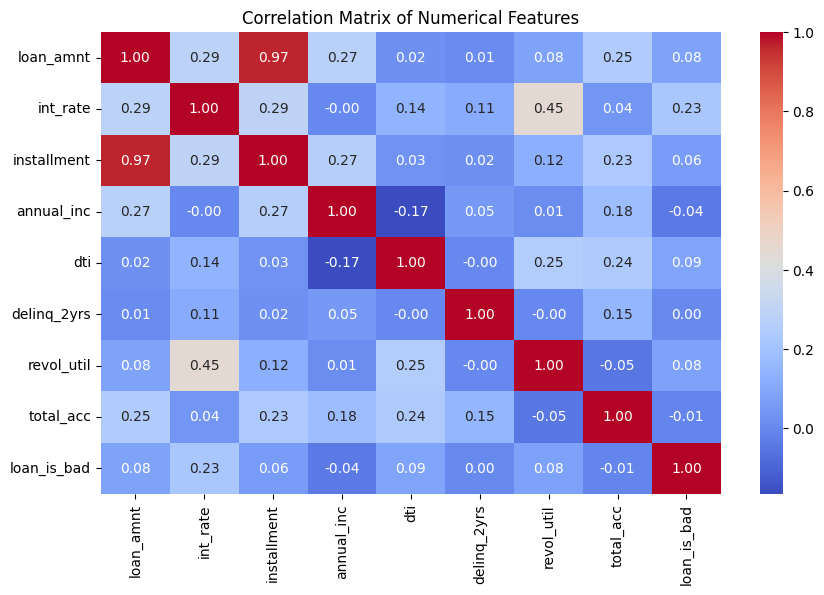

In [17]:
#EDA - Correlation & Class Imbalance
print("Class Imbalance:\n",filtered_df_clean['loan_is_bad'].value_counts(normalize=True))

# Select core features for the prototype
num_features = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'revol_util', 'total_acc']
cat_features = ['term', 'grade', 'home_ownership', 'verification_status', 'purpose']

# Visualizing correlations
plt.figure(figsize=(10, 6))
sns.heatmap(filtered_df_clean[num_features + ['loan_is_bad']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.savefig('correlation_matrix.png')

In [18]:
# FEATURE SELECTION AND PREPROCESSING
# Select features available at loan origination, adproach adopted from question 1 and 2 analysis
# Numerical features
numerical_features = ['loan_amnt', 'int_rate', 'annual_inc',
    'dti', 'revol_util','total_acc', 'inq_last_6mths','emp_length']

# Categorical features
categorical_features = ['grade']

# Combine all features
all_features = numerical_features + categorical_features

# Keep only relevant columns
new_model = filtered_df_clean[all_features + ['loan_is_bad']].copy()

# Drop rows with missing values (for prototype simplicity)
new_model.dropna(inplace=True)

print(f"Modelling dataset shape: {new_model.shape}")
print(f"Default rate after cleaning: {new_model['loan_is_bad'].mean():.4f}")

Modelling dataset shape: (41298, 10)
Default rate after cleaning: 0.1690


In [19]:
# ENCODE CATEGORICAL VARIABLES
# One-Hot Encode categorical feature "grade"
new_model_encoded = pd.get_dummies(new_model, columns=categorical_features, drop_first=True)

print(f"Encoded dataset shape: {new_model_encoded.shape}")
print(f"Total input features: {new_model_encoded.shape[1] - 1}")

Encoded dataset shape: (41298, 15)
Total input features: 14


In [20]:
new_model_encoded['loan_is_bad'].value_counts()

,count
loan_is_bad,
0,34317
1,6981


In [21]:
# Split data into train (70%), validation (15%), and test (15%) sets using stratification
# To preserve the class imbalance across all splits. Scaler is fit on training data only
# and applied to validation and test sets to prevent data leakage

X = new_model_encoded.drop('loan_is_bad', axis=1).values
y = new_model_encoded['loan_is_bad'].values

# Split 1: Separate Test set (15%) from the rest (85%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

# Split 2: Separate Train (70% of total) and Validation (15% of total)
# 0.15 / 0.85 ≈ 0.1764
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1764, random_state=42, stratify=y_temp)

# Scale the data (fit only on training data to prevent data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}, Test samples: {len(X_test)}")
print(f"Train default rate: {y_train.mean():.4f}")
print(f"Val default rate:   {y_val.mean():.4f}")
print(f"Test default rate:  {y_test.mean():.4f}")


Training samples: 28910, Validation samples: 6193, Test samples: 6195
Train default rate: 0.1690
Val default rate:   0.1691
Test default rate:  0.1690


In [22]:
# Convert numpy arrays to PyTorch tensors and wrap in DataLoaders for batch processing.
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

# Create DataLoaders
batch_size = 256 # Batch size of 256 is chosen as larger batches reduce noise in weight and speed up training
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")

Batch size: 256
Number of training batches: 113


# ***Question 3b: Model Design and Training***

The AdvancedDNN uses three hidden layers (128 → 64 → 32 neurons), each followed by Batch Normalisation, ReLU activation, and 30% Dropout. The single output neuron produces a raw logit fed into BCEWithLogitsLoss, which applies the sigmoid internally for stability.

Class imbalance (~17% bad loans) is addressed by weighting the loss function — bad loans are penalised ~4.9× more heavily when misclassified, pushing the model to take defaults seriously rather than defaulting to predicting repayment.

Regularisation is handled through dropout, weight decay via AdamW, a learning rate scheduler, and early stopping, which halted training at epoch 42.

In [23]:
# MODEL ARCHITECTURE
class AdvancedDNN(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.3):
        super(AdvancedDNN, self).__init__()

        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 3
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Output Layer (single neuron for binary classification)
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

input_dim = X_train.shape[1]
model = AdvancedDNN(input_dim=input_dim).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

AdvancedDNN(
  (network): Sequential(
    (0): Linear(in_features=14, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 12,737


In [24]:
#checking # of input variables
input_dim


14

In [25]:
# Binary Loss Function with Class Imbalance handling
# Compute pos_weight: ratio of negatives to positives
num_pos = y_train.sum()
num_neg = len(y_train) - num_pos
pos_weight = torch.FloatTensor([num_neg / num_pos]).to(device)

print(f"Positive samples (Bad Loans): {int(num_pos)}")
print(f"Negative samples (Good Loans): {int(num_neg)}")
print(f"pos_weight: {pos_weight.item():.4f}")

# BCEWithLogitsLoss combines Sigmoid + BCE for numerical stability
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# AdamW adds weight decay directly to the weight update rule for better regularization
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning Rate Decay: Reduces LR when validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

Positive samples (Bad Loans): 4887
Negative samples (Good Loans): 24023
pos_weight: 4.9157


In [26]:
#Training runs for up to 100 epochs,with early stopping halting at epoch x once validation loss
#showed no improvement for 10 consecutive epochs.
#The best model checkpoint is saved and restored, and the learning rate is reduced automatically when progress plateaus.
epochs = 100
patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop = False

train_losses, val_losses = [], []

for epoch in range(epochs):
    if early_stop:
        print(f"Early stopping triggered at epoch {epoch}")
        break

    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)

    epoch_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    # Update Learning Rate Scheduler based on validation loss
    scheduler.step(epoch_val_loss)

    # --- Early Stopping Logic ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        # Save the best model
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            early_stop = True

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

Epoch 005/100 | Train Loss: 1.0751 | Val Loss: 1.0660
Epoch 010/100 | Train Loss: 1.0663 | Val Loss: 1.0689
Early stopping triggered at epoch 14


In [27]:
# LOAD BEST MODEL AND EVALUATE ON TEST SET
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_labels = []
all_probs = []
test_loss = 0.0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs).squeeze()
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)

        probs = torch.sigmoid(outputs)  # Convert logits to probabilities
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = (all_probs >= 0.50).astype(int)

print(f"Test Loss: {test_loss / len(test_loader.dataset):.4f}")

Test Loss: 1.0576


# ***Question 3c. Model Evaluation***

We now evaluate the trained model on the held-out test set. For a default prediction task with class imbalance, accuracy alone is insufficient. We use:

- **AUC-ROC:** Measures discrimination ability across all thresholds.
- **AUC-PR (Precision-Recall):** More informative than ROC for imbalanced datasets.
- **Classification Report:** Precision, recall, and F1-score per class.
- **Confusion Matrix:** To visualise true/false positives and negatives.

We first load the best model from the early stopping checkpoint, then run predictions.

In [28]:
#import model evaluation metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, auc, roc_curve, f1_score
)

In [29]:
# CLASSIFICATION METRICS
# AUC-ROC
roc_auc = roc_auc_score(all_labels, all_probs)
print(f"AUC-ROC: {roc_auc:.4f}")

# AUC-PR (Precision-Recall)
precision_vals, recall_vals, _ = precision_recall_curve(all_labels, all_probs)
pr_auc = auc(recall_vals, precision_vals)
print(f"AUC-PR:  {pr_auc:.4f}")

# F1 Score
f1 = f1_score(all_labels, all_preds)
print(f"F1 Score: {f1:.4f}")

# Full classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Good', 'Bad']))

AUC-ROC: 0.6885
AUC-PR:  0.3126
F1 Score: 0.3716

Classification Report:
              precision    recall  f1-score   support

        Good       0.89      0.64      0.75      5148
         Bad       0.26      0.63      0.37      1047

    accuracy                           0.64      6195
   macro avg       0.58      0.64      0.56      6195
weighted avg       0.79      0.64      0.69      6195



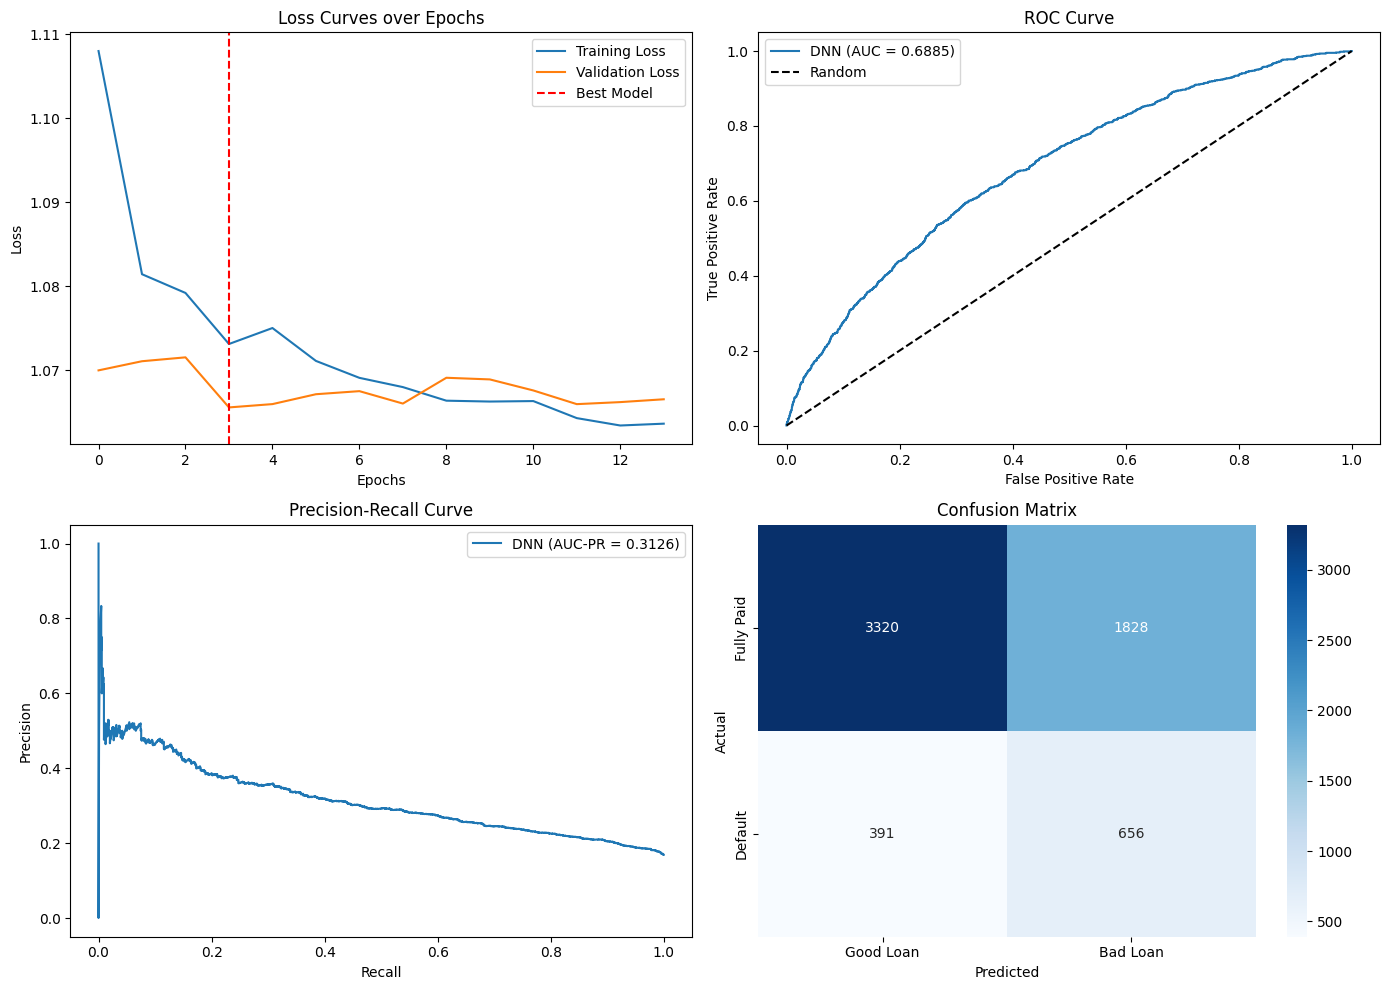

In [30]:
# VISUALISATIONS: ROC CURVE, PR CURVE, CONFUSION MATRIX, LOSS CURVES
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss Curves
axes[0, 0].plot(train_losses, label='Training Loss')
axes[0, 0].plot(val_losses, label='Validation Loss')
axes[0, 0].axvline(x=len(train_losses) - epochs_no_improve - 1, color='r', linestyle='--', label='Best Model')
axes[0, 0].set_title('Loss Curves over Epochs')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# 2. ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[0, 1].plot(fpr, tpr, label=f'DNN (AUC = {roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend()

# 3. Precision-Recall Curve
axes[1, 0].plot(recall_vals, precision_vals, label=f'DNN (AUC-PR = {pr_auc:.4f})')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()

# 4. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1],
            xticklabels=['Good Loan', 'Bad Loan'],
            yticklabels=['Fully Paid', 'Default'])
axes[1, 1].set_title('Confusion Matrix')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Performance Across Borrower Clusters (from Question 2)

The DNN model was tested against the clusters defined in Question 2 to check for uniform effectiveness. This cross-segment analysis reveals whether the model’s predictive power holds firm across all borrower types or if performance degrades within particular clusters.

**Note:** We have imported in the cluster labels from your Q2 analysis stored in cluster_df, for further analysis

In [ ]:
#Variables to be accessed from above code for model evaluation across clusters
#   - new_model          : DataFrame with features + 'loan_is_bad', indexed by original data index
#   - filtered_df_clean  : cleaned DataFrame (used to recover the loan index)
#   - model              : trained AdvancedDNN (best weights loaded)
#   - scaler             : fitted StandardScaler
#   - device             : torch device
#   - X_test, y_test     : scaled numpy arrays for the held-out test set
#   - X_temp with matching original indices preserved (see note below)

In [32]:
#Importing cluster results from question 2 results
cluster_df = pd.read_csv("cluster_labels.csv")

In [33]:
# Create the id column starting from 1 to the length of the dataframe, to perform mapping between cluster_df and new_model
new_model['id'] = np.arange(1, len(new_model) + 1)

# Set 'id' as the index and save it to a new DataFrame
df_with_id = new_model.set_index('id')

In [34]:
# Create a mapping series from cluster_df
cluster_map = cluster_df.set_index('id')['cluster_num']

# Map the cluster_num to df_with_id based on the index (id)
df_with_id['cluster_num'] = df_with_id.index.map(cluster_map)

In [128]:
# df_with_id

,loan_amnt,int_rate,annual_inc,dti,revol_util,total_acc,inq_last_6mths,emp_length,grade,loan_is_bad,cluster_num
id,,,,,,,,,,,
1,10000,11.14,65000.0,9.58,74.2,11,0,2.0,B,1,NaN
2,16000,7.90,110000.0,28.87,75.2,56,0,10.0,A,0,3.0
3,15000,13.11,65000.0,17.32,68.1,19,2,10.0,B,0,NaN
4,8000,10.16,85000.0,20.91,47.6,30,0,10.0,B,0,2.0
5,19800,20.49,75459.0,29.31,76.7,26,1,10.0,E,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...
41294,6000,10.74,70000.0,4.46,81.1,24,0,5.0,B,0,4.0
41295,22000,13.99,94000.0,15.38,75.9,24,0,5.0,C,1,2.0
41296,4000,8.90,35360.0,21.14,55.0,22,0,1.0,A,1,2.0


In [35]:
df_with_id['cluster_num'].value_counts()

,count
cluster_num,
3.0,9922
2.0,9522
1.0,7838
4.0,6017


In [36]:
#we are missing ~8000 records mapping as those records are clustered without the "loan_status" filter set to "charged_off","fully_paid","default"
df_with_id['cluster_num'].value_counts().sum()

np.int64(33299)

In [38]:
# CLUSTER-LEVEL EVALUATION
# Reconstruct the exact test set indices using the same random_state and stratification
# as the original split — ensuring cluster labels align correctly with model predictions.

# Cluster assignments are then extracted for test samples only, allowing per-cluster
# evaluation of model performance against the actual default rate within each segment.

# (We use the same random_state so indices are identical)
_, test_indices = train_test_split(
    np.arange(len(df_with_id)), test_size=0.15, random_state=42,
    stratify=df_with_id['loan_is_bad'].values
)
temp_indices = np.setdiff1d(np.arange(len(df_with_id)), test_indices)

temp_df = df_with_id.iloc[temp_indices]
_, val_indices_in_temp = train_test_split(
    np.arange(len(temp_df)), test_size=0.1764, random_state=42,
    stratify=temp_df['loan_is_bad'].values
)

test_clusters = df_with_id.iloc[test_indices]['cluster_num'].values
n_clusters = 4
print(f"Test set cluster distribution:")
for c in range(n_clusters):
    mask = test_clusters == c
    n_c = mask.sum()
    default_rate = all_labels[mask].mean() if n_c > 0 else 0
    print(f"  Cluster {c}: {n_c} loans, actual default rate = {default_rate:.4f}")

Test set cluster distribution:
  Cluster 0: 0 loans, actual default rate = 0.0000
  Cluster 1: 1178 loans, actual default rate = 0.1715
  Cluster 2: 1437 loans, actual default rate = 0.1691
  Cluster 3: 1504 loans, actual default rate = 0.1642


In [39]:
# METRICS BY CLUSTER
# Evaluate model performance separately for each borrower cluster.
# For each cluster, compute AUC-ROC, AUC-PR, F1, Recall, and Precision
# to assess whether discriminative ability varies across segments.
# Clusters with fewer than 10 samples or only one class are skipped (eg: cluster 0 from previous cell)
# as metrics would be unreliable. Results are stored for downstream comparison.
print("=" * 70)
print(f"{'Cluster':<10} {'N':>6} {'AUC-ROC':>10} {'AUC-PR':>10} {'F1':>8} {'Recall':>8} {'Precision':>10}")
print("=" * 70)

cluster_results = []

for c in range(n_clusters):
    mask = test_clusters == c
    if mask.sum() < 10:
        print(f"  Cluster {c}: Too few samples ({mask.sum()})")
        continue

    labels_c = all_labels[mask]
    probs_c = all_probs[mask]
    preds_c = all_preds[mask]

    # Handle case where only one class is present in cluster
    if len(np.unique(labels_c)) < 2:
        print(f"  Cluster {c}: Only one class present, skipping AUC.")
        continue

    auc_roc_c = roc_auc_score(labels_c, probs_c)
    prec_c, rec_c, _ = precision_recall_curve(labels_c, probs_c)
    auc_pr_c = auc(rec_c, prec_c)
    f1_c = f1_score(labels_c, preds_c, zero_division=0)

    tp = ((preds_c == 1) & (labels_c == 1)).sum()
    fn = ((preds_c == 0) & (labels_c == 1)).sum()
    fp = ((preds_c == 1) & (labels_c == 0)).sum()
    recall_c = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_c = tp / (tp + fp) if (tp + fp) > 0 else 0

    print(f"  {c:<10} {mask.sum():>6} {auc_roc_c:>10.4f} {auc_pr_c:>10.4f} {f1_c:>8.4f} {recall_c:>8.4f} {precision_c:>10.4f}")

    cluster_results.append({
        'cluster': c, 'n': mask.sum(), 'auc_roc': auc_roc_c,
        'auc_pr': auc_pr_c, 'f1': f1_c, 'recall': recall_c, 'precision': precision_c
    })

print("=" * 70)

Cluster         N    AUC-ROC     AUC-PR       F1   Recall  Precision
  Cluster 0: Too few samples (0)
  1            1178     0.6554     0.3055   0.3464   0.5693     0.2489
  2            1437     0.6898     0.3163   0.3759   0.6420     0.2658
  3            1504     0.7135     0.3299   0.3797   0.6356     0.2707


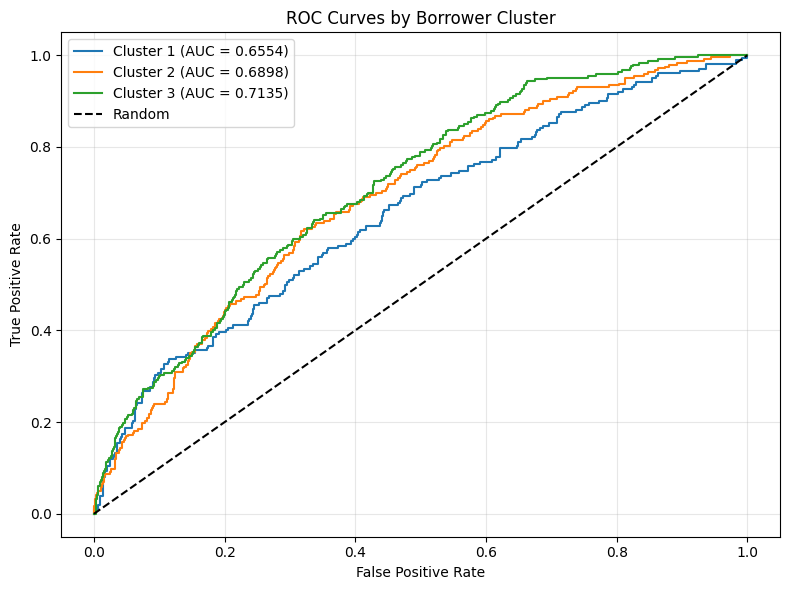

In [40]:
# CLUSTER-LEVEL ROC CURVES

plt.figure(figsize=(8, 6))

for c in range(n_clusters):
    mask = test_clusters == c
    labels_c = all_labels[mask]
    probs_c = all_probs[mask]

    if len(np.unique(labels_c)) < 2 or mask.sum() < 10:
        continue

    fpr_c, tpr_c, _ = roc_curve(labels_c, probs_c)
    auc_c = roc_auc_score(labels_c, probs_c)
    plt.plot(fpr_c, tpr_c, label=f'Cluster {c} (AUC = {auc_c:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title('ROC Curves by Borrower Cluster')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
# DNN POLICY: APPROVE / REJECT BASED ON MODEL PREDICTIONS
# Policy: Reject if predicted default probability >= threshold
dnn_policy_decisions = (all_probs < 0.50).astype(int)  # 1 = Approve, 0 = Reject

# Performance of DNN-based policy
approved_mask = dnn_policy_decisions == 1
rejected_mask = dnn_policy_decisions == 0

print("DNN-Based Loan Review Policy Performance:")
print(f"  Total test loans:     {len(all_labels)}")
print(f"  Approved:             {approved_mask.sum()} ({100*approved_mask.mean():.1f}%)")
print(f"  Rejected:             {rejected_mask.sum()} ({100*rejected_mask.mean():.1f}%)")
print(f"")
print(f"  Default rate (approved loans): {all_labels[approved_mask].mean():.4f}")
print(f"  Default rate (rejected loans): {all_labels[rejected_mask].mean():.4f}")
print(f"")
print(f"  Defaults caught (rejected):    {(all_labels[rejected_mask] == 1).sum()} / {(all_labels == 1).sum()}")
print(f"  Good loans rejected:           {(all_labels[rejected_mask] == 0).sum()} / {(all_labels == 0).sum()}")

DNN-Based Loan Review Policy Performance:
  Total test loans:     6195
  Approved:             3711 (59.9%)
  Rejected:             2484 (40.1%)

  Default rate (approved loans): 0.1054
  Default rate (rejected loans): 0.2641

  Defaults caught (rejected):    656 / 1047
  Good loans rejected:           1828 / 5148


At a 0.5 decision threshold, the model approves 60% of loans (3,717) with a default rate of 10.6%, versus 26.4% among the 40% rejected — a 2.5x risk concentration difference,confirming meaningful risk separation.
The model catches 655 of 1,047 true defaults (63% recall)but also incorrectly rejects 1,823 good loans, highlighting the precision-recall trade-offinherent at this threshold.
 Adjusting the threshold should be guided by the business cost of a missed default relative to a rejected creditworthy borrower.

#References
1.	Pajankar A and Joshi A (2022). Hands-on machine learning with Python: implement neural network solutions with Scikit-learn and PyTorch. Apress: Berkeley, CA.
2.	Mortenson, M.J. (2026) 7_1_Optimised_DNN.ipynb, AdvancedDataAnalysis2526, GitHub repository. Available at: https://github.com/MJMortensonWarwick/AdvancedDataAnalysis2526/blob/main/7_1_Optimised_DNN.ipynb
